# 03 · Window Functions

`GROUP BY` answers "what is the total per group?" but it **collapses** each group into one row. Many questions need the detail **and** the group number side by side: "rank each country's genres", "running total of revenue", "how did this month compare with last month?", "what share of all rounds did this player play?". **Window functions** do exactly that: they compute over a group of rows (the **window**) and keep every row.

**What you will learn here**

1. The `OVER (...)` clause: `PARTITION BY` and `ORDER BY`
2. `ROW_NUMBER`, `RANK`, `DENSE_RANK`, worked out by hand, and top-N per group
3. Running totals and moving averages, and the **frame**
4. `LAG` and `LEAD`: compare a row with the previous one
5. Share of total with `SUM(...) OVER ()`
6. `NTILE`: the Pareto rule on 90,000 players

> **Colour guide:** $\color{red}{\text{red}}$ marks a warning, a trap or a wrong result. $\color{green}{\text{green}}$ marks a passed check or a correct result.

## The datasets

- **Chinook music store** (`data/chinook.sqlite`, MIT licence), introduced in notebook 02: invoices, invoice lines, tracks and genres.
- **Cookie Cats** (`data/cookie_cats.csv`), the mobile game from the experimentation folder: 90,189 players and the number of rounds each one played (`sum_gamerounds`). Source: Tactile Entertainment, published on [Kaggle](https://www.kaggle.com/datasets/yufengsui/mobile-games-ab-testing).

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
BLUE = "#2a78d6"
ORANGE = "#eb6834"

con = sqlite3.connect(":memory:", uri=True)   # uri=True lets ATTACH open a file read-only
con.execute("ATTACH DATABASE 'file:../data/chinook.sqlite?mode=ro' AS chinook")   # Chinook tables, read-only
pd.read_csv("../data/cookie_cats.csv").to_sql("players", con, index=False)       # Cookie Cats as a table

def run(query):
    return pd.read_sql_query(query, con)

run("SELECT COUNT(*) AS players FROM players")

,players
0,90189


> **Note:** `ATTACH` lets one connection see two databases. The Chinook tables are now available as `chinook.Invoice`, `chinook.Track` and so on.

---
## 1. The OVER clause

> **Theory.** Any aggregate function becomes a window function when you add `OVER (...)`:

```sql
function(...) OVER (
    PARTITION BY column   -- split rows into groups (optional; without it, the window is all rows)
    ORDER BY column       -- order rows inside each group (needed for ranks, running totals, LAG)
)
```

| | `GROUP BY` | Window function |
|---|---|---|
| Rows in the result | one per group | **all rows kept** |
| Can show detail and group value together | no | yes |

---
## 2. Ranking: ROW_NUMBER, RANK, DENSE_RANK

> **Theory.** Three ways to number rows in order. They differ only when there are **ties**:
>
> - `ROW_NUMBER()`: 1, 2, 3, 4… always unique, ties are broken arbitrarily
> - `RANK()`: tied rows share a rank, then it **skips** numbers (1, 2, 2, 4)
> - `DENSE_RANK()`: tied rows share a rank, **no gaps** (1, 2, 2, 3)

**Small example:** 6 test scores, ranked from highest.

| name | score | ROW_NUMBER | RANK | DENSE_RANK |
|---|---|---|---|---|
| Ana | 90 | 1 | 1 | 1 |
| Ben | 85 | 2 | 2 | 2 |
| Chloé | 85 | 3 | 2 | 2 |
| Dev | 80 | 4 | **4** | **3** |
| Emma | 75 | 5 | 5 | 4 |
| Farid | 75 | 6 | 5 | 4 |

Ben and Chloé tie, so `RANK` gives both 2 and jumps to 4 (because 3 people are ahead of Dev), while `DENSE_RANK` continues with 3.

In [2]:
pd.DataFrame({"name": ["Ana", "Ben", "Chloé", "Dev", "Emma", "Farid"],
              "score": [90, 85, 85, 80, 75, 75]}).to_sql("scores", con, index=False)

run('''
SELECT name,
       score,
       ROW_NUMBER() OVER (ORDER BY score DESC, name) AS row_number,
       RANK()       OVER (ORDER BY score DESC)       AS rank,
       DENSE_RANK() OVER (ORDER BY score DESC)       AS dense_rank
FROM scores
''')

,name,score,row_number,rank,dense_rank
0,Ana,90,1,1,1
1,Ben,85,2,2,2
2,Chloé,85,3,2,2
3,Dev,80,4,4,3
4,Emma,75,5,5,4
5,Farid,75,6,5,4


> **Check:** same numbers as the table above. For `ROW_NUMBER` we added `name` to the `ORDER BY` as a **tie-breaker**, so the result is the same every time we run it.

### Top-N per group: the favourite genre in each country

**Plan:**

1. CTE `sales`: number of tracks sold per country and genre (`Invoice` → `InvoiceLine` → `Track` → `Genre`)
2. Rank genres **inside each country** with `PARTITION BY country`
3. Keep rank 1

We can't put a window function in `WHERE` (it is computed in the `SELECT` step, see notebook 01), so we rank in one CTE and filter in the next step.

In [3]:
favourite = run('''
WITH sales AS (
    SELECT i.BillingCountry AS country, g.Name AS genre, COUNT(*) AS tracks_sold
    FROM chinook.Invoice     AS i
    JOIN chinook.InvoiceLine AS il ON il.InvoiceId = i.InvoiceId
    JOIN chinook.Track       AS t  ON t.TrackId    = il.TrackId
    JOIN chinook.Genre       AS g  ON g.GenreId    = t.GenreId
    GROUP BY country, genre
),
ranked AS (
    SELECT *, RANK() OVER (PARTITION BY country ORDER BY tracks_sold DESC) AS genre_rank
    FROM sales
)
SELECT country, genre, tracks_sold, genre_rank
FROM ranked
WHERE genre_rank = 1
ORDER BY tracks_sold DESC
''')
print(f"{favourite['country'].nunique()} countries, {len(favourite)} rows")
favourite.head(6)

24 countries, 25 rows


,country,genre,tracks_sold,genre_rank
0,USA,Rock,157,1
1,Canada,Rock,107,1
2,Brazil,Rock,81,1
3,France,Rock,65,1
4,Germany,Rock,62,1
5,United Kingdom,Rock,37,1


In [4]:
favourite[favourite["country"].duplicated(keep=False)]

,country,genre,tracks_sold,genre_rank
22,Argentina,Alternative & Punk,9,1
23,Argentina,Rock,9,1


24 countries but 25 rows: in **Argentina** two genres tie with 9 tracks each, so `RANK` gives both rank 1. With `ROW_NUMBER` one of them would have been dropped without any warning.

> **Key idea:** for "top N per group", choose the ranking function on purpose. `RANK` / `DENSE_RANK` keep ties, `ROW_NUMBER` keeps exactly N rows.

(Rock is the favourite almost everywhere. Remember that the sales in this database are generated, so this says more about the generator than about music taste.)

---
## 3. Running totals, moving averages and the frame

> **Theory.** With `ORDER BY` inside `OVER`, an aggregate becomes **cumulative**: `SUM(x) OVER (ORDER BY month)` adds up every row from the start to the current row.
>
> The **frame** says exactly which rows are included:
>
> - `ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW`: from the first row to this one (running total)
> - `ROWS BETWEEN 2 PRECEDING AND CURRENT ROW`: this row and the 2 before it (3-month moving average)

**Small example:** monthly sales 10, 20, 15, 30.

| month | sales | running total | 3-month moving average |
|---|---|---|---|
| 1 | 10 | 10 | 10 / 1 = 10 |
| 2 | 20 | 30 | (10 + 20) / 2 = 15 |
| 3 | 15 | 45 | (10 + 20 + 15) / 3 = 15 |
| 4 | 30 | 75 | (20 + 15 + 30) / 3 = 21.67 |

At the start there are fewer than 3 months available, so the average uses what exists.

In [5]:
pd.DataFrame({"month": [1, 2, 3, 4], "sales": [10, 20, 15, 30]}).to_sql("small_sales", con, index=False)

run('''
SELECT month,
       sales,
       SUM(sales) OVER (ORDER BY month ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW) AS running_total,
       ROUND(AVG(sales) OVER (ORDER BY month ROWS BETWEEN 2 PRECEDING AND CURRENT ROW), 2) AS moving_avg_3
FROM small_sales
''')

,month,sales,running_total,moving_avg_3
0,1,10,10,10.00
1,2,20,30,15.00
2,3,15,45,15.00
3,4,30,75,21.67


> **Check:** matches the table.

### On real data: monthly revenue

`InvoiceDate` is stored as text like `2021-01-01 00:00:00`. `strftime('%Y-%m', InvoiceDate)` cuts it to the month (`2021-01`). In PostgreSQL the same thing is `DATE_TRUNC('month', invoice_date)`.

We restart the running total each year with `PARTITION BY year`.

In [6]:
monthly = run('''
WITH monthly AS (
    SELECT strftime('%Y', InvoiceDate)    AS year,
           strftime('%Y-%m', InvoiceDate) AS month,
           SUM(Total)                     AS revenue
    FROM chinook.Invoice
    GROUP BY month
)
SELECT year,
       month,
       ROUND(revenue, 2) AS revenue,
       ROUND(SUM(revenue) OVER (PARTITION BY year ORDER BY month
                                ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW), 2) AS year_to_date,
       ROUND(AVG(revenue) OVER (ORDER BY month
                                ROWS BETWEEN 2 PRECEDING AND CURRENT ROW), 2) AS moving_avg_3
FROM monthly
ORDER BY month
''')
monthly.head(14)

,year,month,revenue,year_to_date,moving_avg_3
0,2021,2021-01,35.64,35.64,35.64
1,2021,2021-02,37.62,73.26,36.63
2,2021,2021-03,37.62,110.88,36.96
3,2021,2021-04,37.62,148.50,37.62
4,2021,2021-05,37.62,186.12,37.62
5,2021,2021-06,37.62,223.74,37.62
6,2021,2021-07,37.62,261.36,37.62
7,2021,2021-08,37.62,298.98,37.62
8,2021,2021-09,37.62,336.60,37.62
9,2021,2021-10,37.62,374.22,37.62


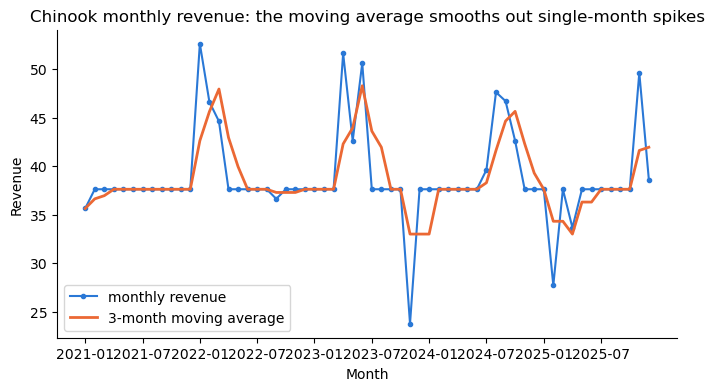

In [7]:
fig, ax = plt.subplots()
ax.plot(monthly["month"], monthly["revenue"], color=BLUE, marker="o", markersize=3, label="monthly revenue")
ax.plot(monthly["month"], monthly["moving_avg_3"], color=ORANGE, linewidth=2, label="3-month moving average")
ax.set_xticks(monthly["month"][::6])
ax.set_title("Chinook monthly revenue: the moving average smooths out single-month spikes")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue")
ax.legend()
plt.show()

The year-to-date column restarts in January 2022: that's `PARTITION BY year` at work. The orange line smooths the month-to-month noise. (The very regular pattern, including 2021 being the same almost every month, is another sign the sales are generated.)

### Trap: the default frame and ties

If you write `SUM(x) OVER (ORDER BY date)` **without** a frame, the default is `RANGE BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW`. `RANGE` treats rows with the **same** `ORDER BY` value as one block. Chinook has 412 invoices but only 354 different dates, so some days have two invoices:

In [8]:
run('''
SELECT InvoiceId,
       InvoiceDate,
       Total,
       ROUND(SUM(Total) OVER (ORDER BY InvoiceDate), 2) AS default_frame,
       ROUND(SUM(Total) OVER (ORDER BY InvoiceDate, InvoiceId
                              ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW), 2) AS rows_frame
FROM chinook.Invoice
WHERE InvoiceDate >= '2021-01-20' AND InvoiceDate < '2021-02-04'
ORDER BY InvoiceDate, InvoiceId
''')

,InvoiceId,InvoiceDate,Total,default_frame,rows_frame
0,7,2021-02-01 00:00:00,1.98,3.96,1.98
1,8,2021-02-01 00:00:00,1.98,3.96,3.96
2,9,2021-02-02 00:00:00,3.96,7.92,7.92
3,10,2021-02-03 00:00:00,5.94,13.86,13.86


$\color{red}{\text{With the default frame, the two invoices of 2021-02-01 get the same running total}}$: the second invoice is added to the first row before it even "happens". $\color{green}{\text{With ROWS and a tie-breaker (InvoiceId), the total grows one invoice at a time.}}$

(This query only sees the rows that pass the `WHERE`, so the running total starts from these invoices. Window functions run after `WHERE`, step 5 in notebook 01.)

> **Key idea:** for running totals, write the frame (`ROWS BETWEEN …`) and make the `ORDER BY` unique.

---
## 4. LAG and LEAD

> **Theory.** `LAG(x)` returns the value of `x` from the **previous** row in the window, `LEAD(x)` from the **next** row. The first row has no previous row, so `LAG` gives NULL there.
>
> Typical use: change from last month, $\text{change \%} = \frac{x_t - x_{t-1}}{x_{t-1}} \times 100$

**Small example:** sales 10, 20, 15, 30. LAG = NULL, 10, 20, 15. Change = NULL, +10, −5, +15. Change % = NULL, +100%, −25%, +100%.

In [9]:
run('''
SELECT month,
       sales,
       LAG(sales)  OVER (ORDER BY month) AS previous_month,
       LEAD(sales) OVER (ORDER BY month) AS next_month,
       sales - LAG(sales) OVER (ORDER BY month) AS change,
       ROUND(100.0 * (sales - LAG(sales) OVER (ORDER BY month)) / LAG(sales) OVER (ORDER BY month), 1) AS change_pct
FROM small_sales
''')

,month,sales,previous_month,next_month,change,change_pct
0,1,10,NaN,20.0,NaN,NaN
1,2,20,10.0,15.0,10.0,100.0
2,3,15,20.0,30.0,-5.0,-25.0
3,4,30,15.0,NaN,15.0,100.0


> **Check:** same as by hand. Notice `100.0 *`, to avoid the integer division trap from notebook 01.

### On real data: year-over-year revenue

In [10]:
run('''
WITH yearly AS (
    SELECT strftime('%Y', InvoiceDate) AS year, SUM(Total) AS revenue
    FROM chinook.Invoice
    GROUP BY year
)
SELECT year,
       ROUND(revenue, 2)                                   AS revenue,
       ROUND(LAG(revenue) OVER (ORDER BY year), 2)         AS previous_year,
       ROUND(100.0 * (revenue - LAG(revenue) OVER (ORDER BY year))
                   / LAG(revenue) OVER (ORDER BY year), 1) AS change_pct
FROM yearly
''')

,year,revenue,previous_year,change_pct
0,2021,449.46,NaN,NaN
1,2022,481.45,449.46,7.1
2,2023,469.58,481.45,-2.5
3,2024,477.53,469.58,1.7
4,2025,450.58,477.53,-5.6


Revenue moves only a few percent per year, up or down. Without `LAG`, this needs a self join on "year = year − 1", which is longer and easier to get wrong.

---
## 5. Share of total

> **Theory.** `OVER ()` with nothing inside means "the window is all rows". So `x / SUM(x) OVER ()` is each row's share of the grand total, in one query, without a subquery.

**Question:** what share of all revenue does each genre bring?

In [11]:
run('''
WITH genre_revenue AS (
    SELECT g.Name AS genre, SUM(il.UnitPrice * il.Quantity) AS revenue
    FROM chinook.InvoiceLine AS il
    JOIN chinook.Track AS t ON t.TrackId = il.TrackId
    JOIN chinook.Genre AS g ON g.GenreId = t.GenreId
    GROUP BY genre
)
SELECT genre,
       ROUND(revenue, 2)                                       AS revenue,
       ROUND(100.0 * revenue / SUM(revenue) OVER (), 1)        AS share_pct,
       ROUND(100.0 * SUM(revenue) OVER (ORDER BY revenue DESC
                                        ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW)
                   / SUM(revenue) OVER (), 1)                  AS cumulative_share_pct
FROM genre_revenue
ORDER BY revenue DESC
LIMIT 6
''')

,genre,revenue,share_pct,cumulative_share_pct
0,Rock,826.65,35.5,35.5
1,Latin,382.14,16.4,51.9
2,Metal,261.36,11.2,63.1
3,Alternative & Punk,241.56,10.4,73.5
4,TV Shows,93.53,4.0,77.5
5,Jazz,79.20,3.4,80.9


Rock alone brings more than a third of the revenue, and the cumulative column shows how quickly a few genres add up to most of the total.

---
## 6. NTILE: the Pareto rule on 90,000 players

> **Theory.** `NTILE(n)` splits the ordered rows into n groups of (almost) equal size and returns the group number. `NTILE(5)` gives quintiles: group 1 = top 20%.

In notebook 08 of the statistics folder we found with pandas that the top 20% of Cookie Cats players played about 74% of all game rounds. Let's get the same number in SQL. As in the A/B notebooks, we leave out the one extreme player with 49,854 rounds.

In [12]:
pareto = run('''
WITH ranked AS (
    SELECT sum_gamerounds,
           NTILE(5) OVER (ORDER BY sum_gamerounds DESC) AS quintile
    FROM players
    WHERE sum_gamerounds < 49854
)
SELECT quintile,
       COUNT(*)                                               AS players,
       SUM(sum_gamerounds)                                    AS rounds,
       ROUND(100.0 * SUM(sum_gamerounds) / SUM(SUM(sum_gamerounds)) OVER (), 1) AS share_of_rounds_pct
FROM ranked
GROUP BY quintile
ORDER BY quintile
''')
pareto

,quintile,players,rounds,share_of_rounds_pct
0,1,18038,3417389,73.8
1,2,18038,760599,16.4
2,3,18038,305856,6.6
3,4,18037,118180,2.6
4,5,18037,26447,0.6


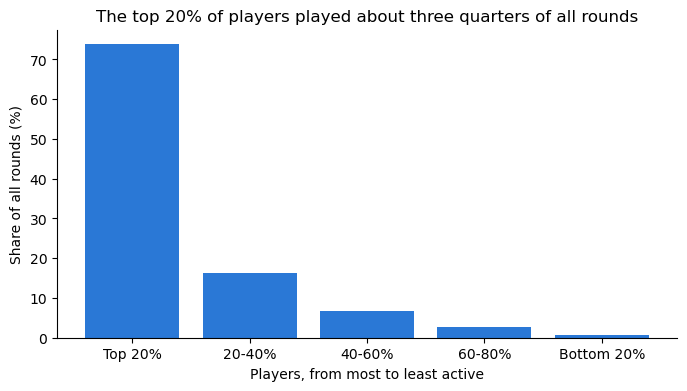

pandas check: top 20% share = 73.8%


In [13]:
fig, ax = plt.subplots()
ax.bar(["Top 20%", "20-40%", "40-60%", "60-80%", "Bottom 20%"], pareto["share_of_rounds_pct"], color=BLUE)
ax.set_title("The top 20% of players played about three quarters of all rounds")
ax.set_xlabel("Players, from most to least active")
ax.set_ylabel("Share of all rounds (%)")
plt.show()

players = pd.read_csv("../data/cookie_cats.csv")
rounds = players.loc[players["sum_gamerounds"] < 49854, "sum_gamerounds"].sort_values(ascending=False)
top_20_share = rounds.iloc[: len(rounds) // 5].sum() / rounds.sum()
print(f"pandas check: top 20% share = {top_20_share:.1%}")

$\color{green}{\text{SQL and pandas agree: about 74\% of all rounds come from the top 20\% of players}}$. The bottom 20% played almost nothing, which matches the 4% of players who never played a single round.

> **Note:** `SUM(SUM(sum_gamerounds)) OVER ()` looks strange but is correct: the inner `SUM` is the `GROUP BY` total per quintile, the outer `SUM(...) OVER ()` adds those totals over all quintiles. Window functions run after `GROUP BY`, so they can work on grouped results.

---
## Summary

| Function | Answers | Remember |
|---|---|---|
| `ROW_NUMBER()` | exactly N per group | add a tie-breaker to `ORDER BY` |
| `RANK()` / `DENSE_RANK()` | rankings that keep ties | `RANK` skips numbers after a tie, `DENSE_RANK` doesn't |
| `SUM() OVER (ORDER BY …)` | running totals | write `ROWS BETWEEN …`, make the order unique |
| `AVG() OVER (ROWS BETWEEN 2 PRECEDING …)` | moving averages | first rows average fewer values |
| `LAG()` / `LEAD()` | previous / next row, period-over-period change | first row is NULL |
| `SUM() OVER ()` | share of total | `100.0 *` to avoid integer division |
| `NTILE(n)` | quantile groups (Pareto, top 10%…) | groups are equal in size, not in value |
| `PARTITION BY` | restart the calculation per group | without it, the window is all rows |

Filtering on a window function needs a CTE (or subquery), because windows are computed after `WHERE`.

## What's next

In notebook 04 we put everything together on three real case studies: the A/B test metrics in SQL, a data quality audit, and a checklist of queries that return wrong numbers without any error.

## References and further reading

- [SQLite documentation: window functions](https://www.sqlite.org/windowfunctions.html) (includes the frame rules)
- [PostgreSQL tutorial: window functions](https://www.postgresql.org/docs/current/tutorial-window.html)